# Day 2: Tree-Based Models

### 1. 🚀 Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, r2_score, root_mean_squared_error

%matplotlib inline

### 2. 🌲 Part A: Decision Trees (The Concept)

**Task:** Load a classification dataset (e.g., Breast Cancer or Titanic).

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

**Task:** Preprocessing
1. Load `X` and `y`.
2. Perform `train_test_split`.
3. **Note:** Tree models do *not* require feature scaling. Write a markdown comment explaining why.

In [3]:
X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

#No need of feature scaling for Tree-Based Models because they make decisions based on thresholds of individual 
#feature values, not on the absolute magnitude or distance between data points, making them invariant to feature scaling.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#### Model 1: `DecisionTreeClassifier`

**Task:** 
1. Create an instance: `model_dt = DecisionTreeClassifier(random_state=42)`
2. Train the model: `model_dt.fit(X_train, y_train)`
3. Make predictions: `y_pred_dt = model_dt.predict(X_test)`
4. Evaluate:
    - Print the Classification Report for *both* the **test set** (`y_test`, `y_pred_dt`) and the **training set** (`y_train`, `model_dt.predict(X_train)`).
    - **Key Concept: Overfitting:** Write a markdown note observing the difference in accuracy. This is overfitting.

In [4]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train,y_train)
y_pred_dt = model_dt.predict(X_test)

print(f"Classification Report : Train Set\n{classification_report(y_train, model_dt.predict(X_train))}")
print(f"Classification Report : Test Set\n{classification_report(y_test, y_pred_dt)}")

Classification Report : Train Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       145
           1       1.00      1.00      1.00       236

    accuracy                           1.00       381
   macro avg       1.00      1.00      1.00       381
weighted avg       1.00      1.00      1.00       381

Classification Report : Test Set
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        67
           1       0.95      0.93      0.94       121

    accuracy                           0.92       188
   macro avg       0.91      0.92      0.91       188
weighted avg       0.92      0.92      0.92       188



## **Observation: Overfitting**

From the classification reports, we observe the following:

- **Training Set Accuracy:** The model achieves a perfect accuracy of 100% on the training set, indicating that it has memorized the training data completely.
- **Test Set Accuracy:** The accuracy on the test set is 92%, which is significantly lower than the training accuracy.

This discrepancy between the training and test accuracies is a classic sign of **overfitting**. The model is too complex and has learned the noise and specific patterns in the training data, which do not generalize well to unseen data.

#### Visualization

**Task:** 
1. Create a large figure: `plt.figure(figsize=(20,10))`
2. Use `plot_tree` to visualize your trained decision tree.
   `plot_tree(model_dt, feature_names=X.columns, class_names=['Class 0', 'Class 1'], filled=True)`

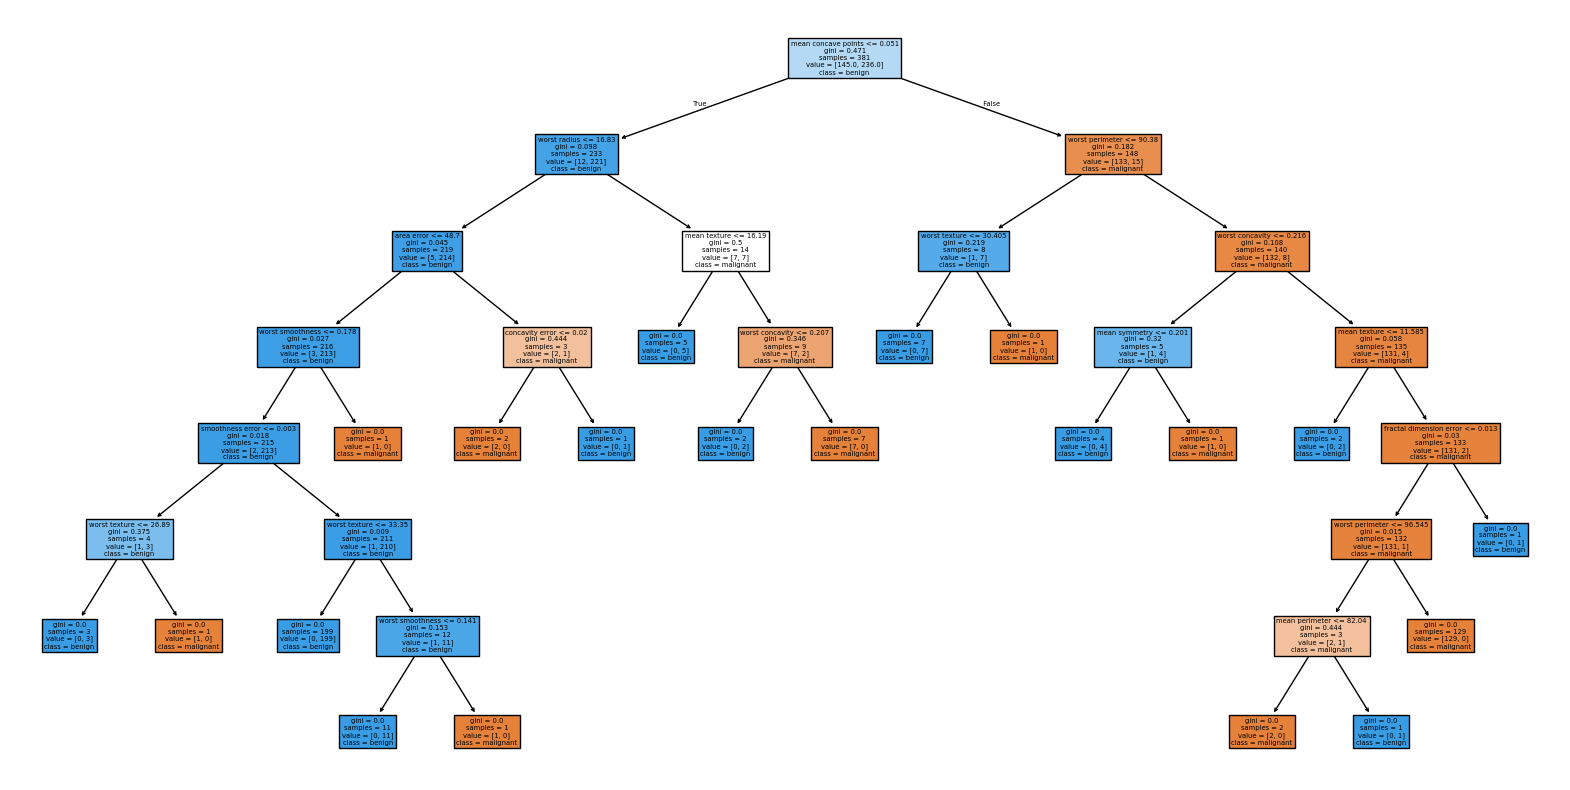

In [5]:
plt.figure(figsize=(20,10))
plot_tree(model_dt, feature_names=feature_names, class_names= target_names, filled=True)
plt.show()

---

### 3. 🌳 Part B: Random Forests (The Solution to Overfitting)

**Concept:** An **Ensemble** model. Fixes overfitting by building hundreds of "dumber" trees on random subsets of data and features, then taking a majority vote.

#### Model 2: `RandomForestClassifier`

**Task:** 
1. Create an instance: `model_rf = RandomForestClassifier(n_estimators=100, random_state=42)`
2. Train the model: `model_rf.fit(X_train, y_train)`
3. Make predictions: `y_pred_rf = model_rf.predict(X_test)`
4. Evaluate:
    - Print the Classification Report for the **test set** and **training set**.
    - Write a markdown note comparing the `test` accuracy of the Random Forest to the Decision Tree. Also, note the `train` accuracy. (It should no longer be 100%, which is a good sign!).

In [6]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train,y_train)
y_pred_dt = model_rf.predict(X_test)

print(f"Classification Report : Train Set\n{classification_report(y_train, model_rf.predict(X_train))}")
print(f"Classification Report : Test Set\n{classification_report(y_test, y_pred_dt)}")

Classification Report : Train Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       145
           1       1.00      1.00      1.00       236

    accuracy                           1.00       381
   macro avg       1.00      1.00      1.00       381
weighted avg       1.00      1.00      1.00       381

Classification Report : Test Set
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        67
           1       0.96      0.98      0.97       121

    accuracy                           0.96       188
   macro avg       0.96      0.95      0.95       188
weighted avg       0.96      0.96      0.96       188



### Comparison of Test and Train Accuracy: Decision Tree vs Random Forest

#### Decision Tree:
- **Training Accuracy:** The Decision Tree model achieves a perfect accuracy of 100% on the training set, indicating that it has completely memorized the training data.
- **Test Accuracy:** The test set accuracy is 92%, which is significantly lower than the training accuracy. This discrepancy highlights that the Decision Tree model is overfitting the training data.

#### Random Forest:
- **Training Accuracy:** Similar to the Decision Tree, the Random Forest model also achieves a perfect accuracy of 100% on the training set.
- **Test Accuracy:** The test set accuracy is 96%, which is higher than the Decision Tree's test accuracy. This improvement demonstrates that the Random Forest model generalizes better to unseen data, thanks to its ensemble approach that reduces overfitting.

#### Key Observation:
The Random Forest model outperforms the Decision Tree on the test set, achieving a higher accuracy and better generalization. This is due to the ensemble technique, which combines multiple trees and reduces the risk of overfitting by introducing randomness in the training process.

#### Key Concept: Feature Importance

**Task:** 
1. Get importances: `importances = model_rf.feature_importances_`
2. Create a Pandas Series to view them: `pd.Series(importances, index=X.columns).sort_values(ascending=False)`
3. Use Seaborn to plot a bar chart of the feature importances.

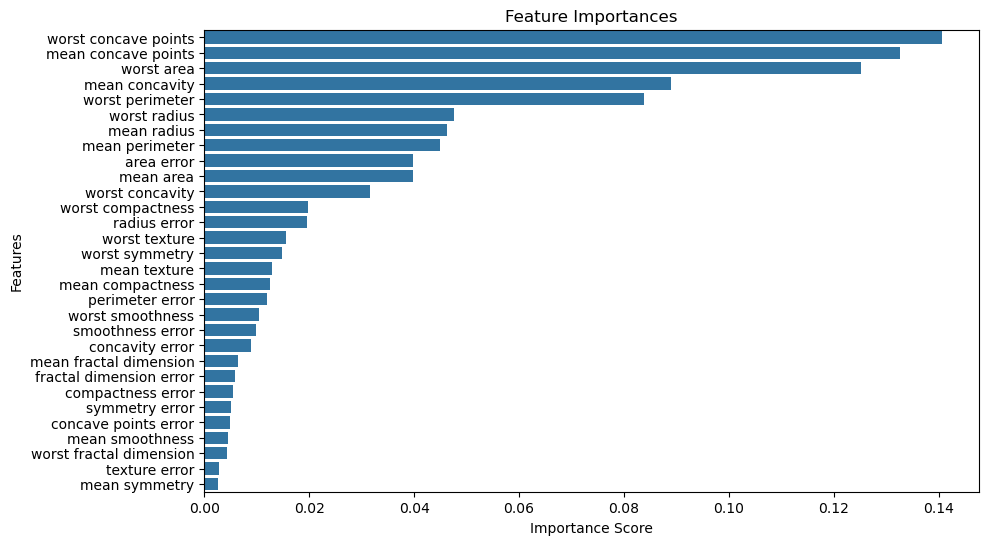

In [7]:
importances = model_rf.feature_importances_
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_series, y=importance_series.index)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

---

### 4. 🏘️ Part C: Trees for Regression (Brief)

**Task:** Load a regression dataset (e.g., California Housing).

In [8]:
df = pd.read_csv(r"datasets/House Price Prediction Dataset.csv")
X = df.drop(columns=['Price_USD','Condition'])
y = df.Price_USD

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#### Model 3: `RandomForestRegressor`

**Task:** 
1. Create, train, and predict using `RandomForestRegressor`.
2. Evaluate using RMSE and R².
3. Check `feature_importances_` for this regression task.

In [9]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train,y_train)
y_pred_dt = model_rf.predict(X_test)

print(f"RMSE : {root_mean_squared_error(y_test,y_pred_dt)}")
print(f"R^2 : {r2_score(y_test,y_pred_dt)}")

RMSE : 83796.40505415492
R^2 : 0.8801094867143314


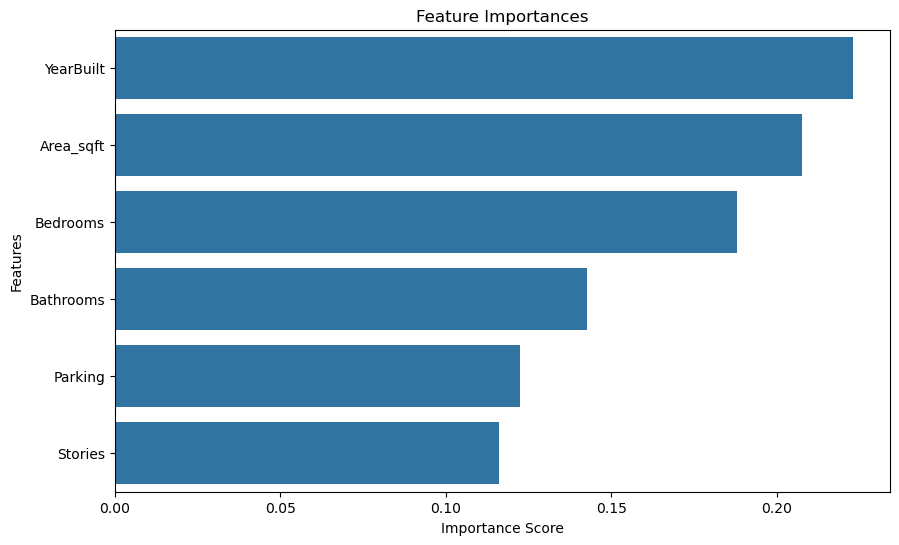

In [10]:
importances = model_rf.feature_importances_
importance_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_series, y=importance_series.index)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()